# Predicting U.S. Inflation Using Economic Indicators

This project predicts U.S. year-over-year inflation using unemployment, the federal funds rate, and the 10-year Treasury yield. The goal is to test whether basic economic indicators can explain inflation movement over time.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Download data directly from FRED
cpi = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL")
unrate = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE")
fedfunds = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS")
gs10 = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=GS10")

print(cpi.head())
print(unrate.head())
print(fedfunds.head())
print(gs10.head())


  observation_date  CPIAUCSL
0       1947-01-01     21.48
1       1947-02-01     21.62
2       1947-03-01     22.00
3       1947-04-01     22.00
4       1947-05-01     21.95
  observation_date  UNRATE
0       1948-01-01     3.4
1       1948-02-01     3.8
2       1948-03-01     4.0
3       1948-04-01     3.9
4       1948-05-01     3.5
  observation_date  FEDFUNDS
0       1954-07-01      0.80
1       1954-08-01      1.22
2       1954-09-01      1.07
3       1954-10-01      0.85
4       1954-11-01      0.83
  observation_date  GS10
0       1953-04-01  2.83
1       1953-05-01  3.05
2       1953-06-01  3.11
3       1953-07-01  2.93
4       1953-08-01  2.95


## Step 2: Cleaning and Merging Data

The datasets are combined into a single table using the date as a common reference. This allows us to analyze relationships between inflation, unemployment, and interest rates in one place.

In [9]:
# Rename columns so they are easier to use
cpi.columns = ["DATE", "CPI"]
unrate.columns = ["DATE", "UNRATE"]
fedfunds.columns = ["DATE", "FEDFUNDS"]
gs10.columns = ["DATE", "GS10"]

# Merge all datasets by date
df = cpi.merge(unrate, on="DATE")
df = df.merge(fedfunds, on="DATE")
df = df.merge(gs10, on="DATE")

# Convert date column to real dates
df["DATE"] = pd.to_datetime(df["DATE"])

# Sort by date
df = df.sort_values("DATE")

df.head()

,DATE,CPI,UNRATE,FEDFUNDS,GS10
0,1954-07-01,26.86,5.8,0.80,2.30
1,1954-08-01,26.85,6.0,1.22,2.36
2,1954-09-01,26.81,6.1,1.07,2.38
3,1954-10-01,26.72,5.7,0.85,2.43
4,1954-11-01,26.78,5.3,0.83,2.48


## Step 3: Create Inflation Variable

Inflation is calculated as the year-over-year percentage change in the Consumer Price Index (CPI). This converts raw price levels into a meaningful measure of how quickly prices are increasing.

In [10]:
# Inflation = percent change in CPI from 12 months ago
df["Inflation"] = df["CPI"].pct_change(12, fill_method=None) * 100

# Drop empty rows caused by percent change
df = df.dropna()

df.head()

,DATE,CPI,UNRATE,FEDFUNDS,GS10,Inflation
12,1955-07-01,26.76,4.0,1.68,2.90,-0.372301
13,1955-08-01,26.72,4.2,1.96,2.97,-0.484171
14,1955-09-01,26.85,4.1,2.18,2.97,0.149198
15,1955-10-01,26.82,4.3,2.24,2.88,0.374251
16,1955-11-01,26.88,4.2,2.35,2.89,0.373413


## Step 4: Visualizing Inflation Over Time

This graph shows how inflation has changed over time. Visualizing the data helps identify trends, spikes, and periods of stability before building a predictive model.

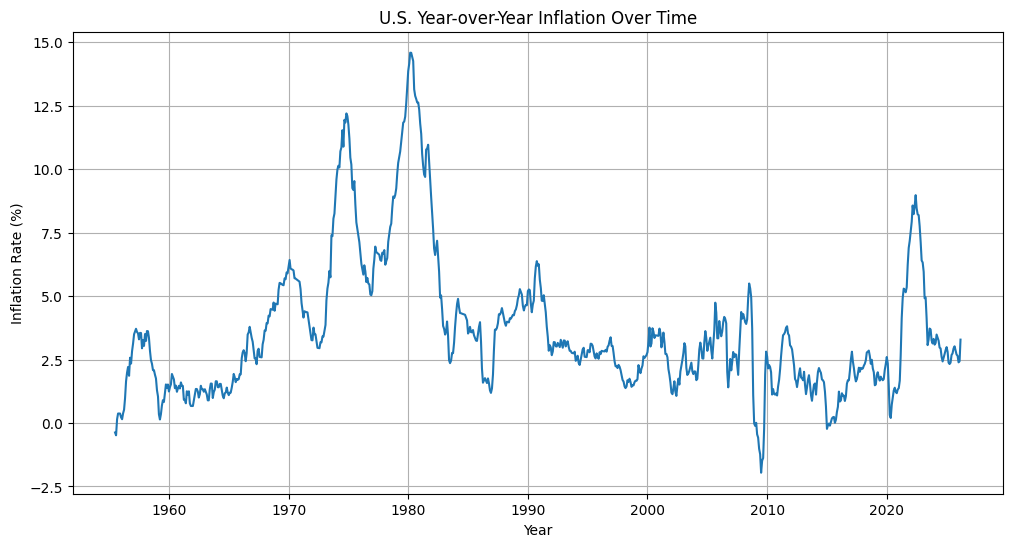

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["Inflation"])
plt.title("U.S. Year-over-Year Inflation Over Time")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.grid(True)
plt.show()

## Step 5: Building a Prediction Model

A linear regression model is used to predict inflation based on unemployment and interest rates. The dataset is split into training and testing portions to evaluate how well the model performs on unseen data.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Inputs: things we use to predict inflation
X = df[["UNRATE", "FEDFUNDS", "GS10"]]

# Output: what we are trying to predict
y = df["Inflation"]

# Keep time order: first 80% train, last 20% test
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Measure error
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 1.380028782330607
Root Mean Squared Error: 2.3981082674513434


## Step 6: Comparing Predictions to Actual Values

The model's predicted inflation values are compared against actual values. This helps visually assess how closely the model captures real-world trends.

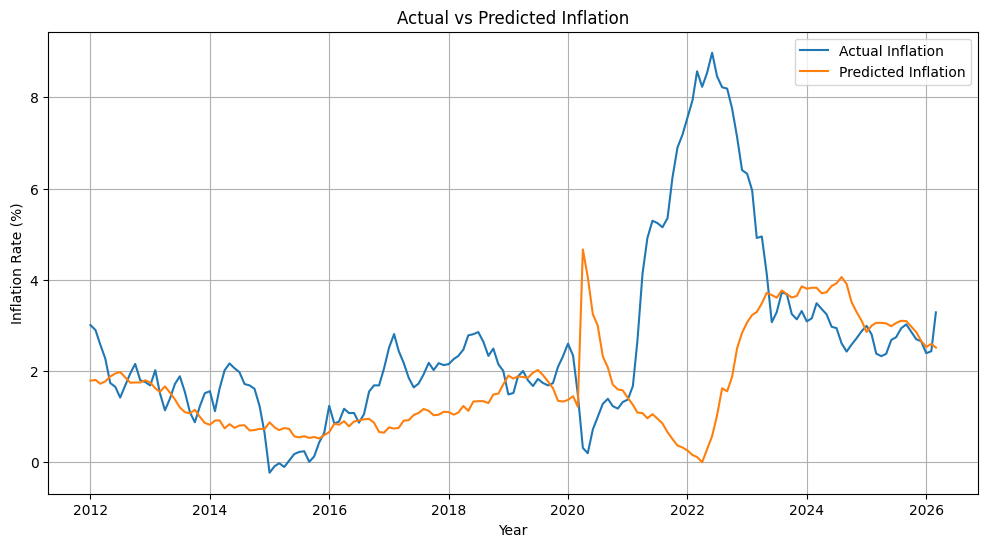

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df["DATE"].iloc[split_index:], y_test.values, label="Actual Inflation")
plt.plot(df["DATE"].iloc[split_index:], predictions, label="Predicted Inflation")
plt.title("Actual vs Predicted Inflation")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

My project demonstrates how economic indicators such as unemployment and interest rates can be used to estimate inflation. The model captures general trends, though accuracy could be improved with more advanced techniques and additional variables.